[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cyneuro/4590_Colabs/blob/main/3_1_FirstOrderSystems.ipynb)

# Set 3_1 — The World of First-Order Systems: A Modeling Process
**Author:** Nair SS, et al., Electrical Engineering and Computer Science, University of Missouri-Columbia, Columbia, MO, USA

---
### What This Notebook Is About
You've already built one first-order system in this course: the passive neuron membrane in Set 3. This notebook steps back and asks a bigger question — **what do a falling ball, a car, a draining tank, and a charging neuron actually have in common?**

The answer: they all follow the *same modeling process*, even though they come from completely different fields. This notebook makes that process explicit, applies it to four very different systems, and then pushes you to apply it yourself — to a coupled predator-prey system, to new scenarios you haven't seen, and finally to a system you find on your own.

**This is a skill-transfer exercise as much as a content one.** The goal isn't just to understand four examples — it's to walk away able to look at *any* new dynamic system and know how to start modeling it.

---
### 📋 A Note on This Notebook
Several points in this notebook ask you to **photograph a hand-written sketch** and upload it — not type your answer, sketch it on paper first. This is deliberate: a genuine hand-sketch is a much stronger sign of real understanding than typed text, and far harder to produce without actually having thought it through yourself.

There are **four upload checkpoints** in this notebook, each testing something different — building a system's model for the first time, sketching a coupled (two-variable) system, applying the process to something you found yourself, and finally synthesizing everything into one summary table from memory. Treat each one as a real checkpoint, not a formality.

---
## The Puzzle
Consider four systems, each tracking a different quantity over time:

| # | System | What changes over time |
|---|---|---|
| 1 | A ball thrown straight up | its height |
| 2 | A car accelerating away from a stoplight | its velocity |
| 3 | A tank filling from a faucet while also draining | the fluid level |
| 4 | A neuron receiving injected current | its membrane voltage |

**Activity — Ask AI:** *"These four systems seem to come from completely different fields — mechanics, fluid dynamics, and neuroscience. Despite that, what mathematical structure might they all share? Why might an engineer say they all have 'the same kind of dynamics'?"* Paste the response.

All four systems can be modeled using first-order differential equations, which describe how a quantity changes over time based on its current state and external inputs.

Each system has a state variable (height, velocity, fluid level, or membrane voltage) whose rate of change depends on forces, flows, or electrical currents. For example, a ball's velocity changes due to gravity, a tank's fluid level changes due to the difference between inflow and outflow, and a neuron's membrane voltage changes based on injected current and electrical properties.

An engineer might say they have the “same kind of dynamics” because, despite representing different physical phenomena, they can share the same mathematical structure: a state variable, a time-dependent rate of change, and inputs or parameters that govern its behavior. This allows engineers to use similar mathematical tools to analyze, predict, and control all four systems.


*Your Answer Here — in your own words, before reading further, what's your own guess?*

The systems are all first order, with a non linear change in variable.

### The Answer: They're All First-Order Systems
**All four of these systems have first-order dynamics.** Each one is governed by a differential equation of the same general shape you first met in Set 1:

$$\tau \dot y(t) + y(t) = K u(t)$$

— just with a different $y$, a different $u$, and a different physical law producing that equation each time. Two families of laws keep showing up:

| System | Dependent variable | Underlying Law(s) |
|---|---|---|
| Ball thrown up | height | Newton's 2nd law |
| Driving a car | velocity | Newton's 2nd law |
| Tank filling | fluid level | Conservation of volume |
| Neuron charging | voltage | Conservation of charge (+ Ohm's law) |

Notice the neuron row already has **two** laws working together — a preview of why the summary table you build at the end of this notebook is titled *Underlying Laws*, plural.

---
## The Process
Every system above — and every new one you'll model in this notebook — gets built the same seven-step way. Keep this checklist visible; you'll use it repeatedly.

1. **Sketch the system.** Draw the physical setup. What's flowing, moving, or accumulating?
2. **Identify the state variable.** What single quantity, as a function of time, describes the system?
3. **Identify the underlying law(s).** Newton's 2nd law? A conservation law? Something else?
4. **Write the balance equation.** Translate the law into words: *rate of change = (what's coming in) − (what's leaving)*, or $F=ma$, or similar.
5. **Identify parameters and units.** What are the actual numbers, and what do they physically mean?
6. **Solve or simulate.** Analytically if possible; Euler's method (from Set 1) otherwise.
7. **Interpret.** Does the behavior make physical sense? Check limiting cases.

---
## Example 1: A Ball Thrown Straight Up
### Step 1 — Sketch
Picture a ball launched straight upward from your hand, height $h$ measured from the ground, gravity pulling it back down.

### Step 2 — State Variable
Height $h(t)$.

### Step 3 — Underlying Law
**Newton's 2nd law:** $F = ma$. The only force acting (ignoring air resistance) is gravity, $-mg$ (negative, since it points downward while $h$ points up).

### Step 4 — Balance Equation
$$-mg = m\ddot h$$
$$\ddot h = -g$$

This is a **second-order** equation — it involves $\ddot h$, the second derivative. But here's a trick worth knowing: let $v = \dot h$ (velocity). Then $\dot v = \ddot h$, so:

$$\dot v = -g$$

**A first-order equation in $v$.** Any second-order equation in position can be rewritten as a first-order equation in velocity this way — a genuinely reusable trick, not a one-off.

### 🚫 By-Hand Drill — No AI, No Code
With $v(0) = \dot h(0) = 1$ m/s (thrown gently upward) and $g = 9.8$ m/s², solve $\dot v = -g$ by hand for $v(t)$, then find the time at which the ball reaches its peak (where $v=0$).

*Your Answer Here (show your work):*
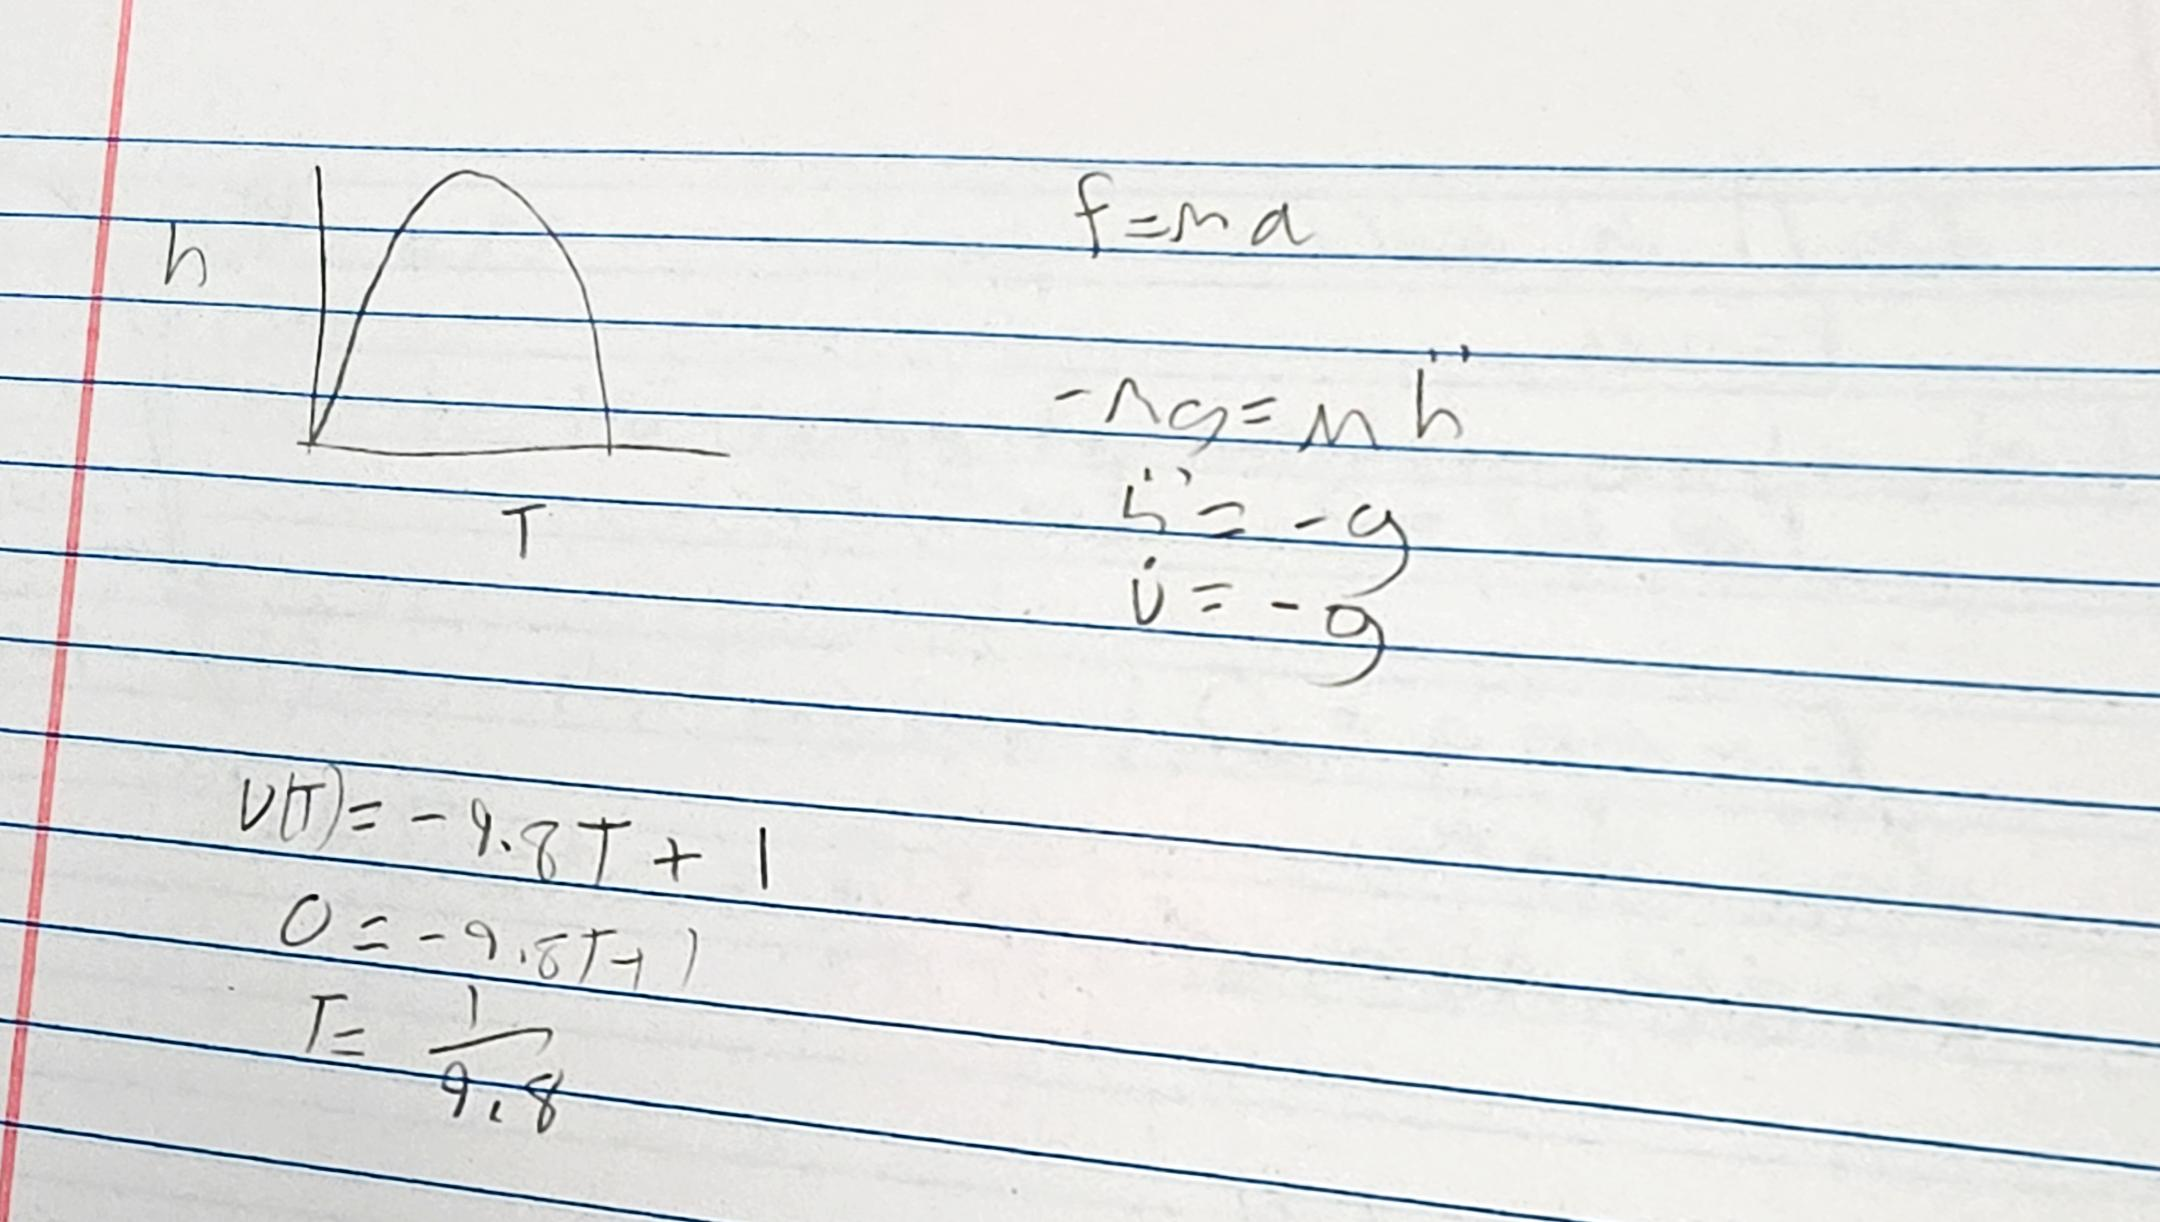

### Steps 5-6 — Parameters and Simulation
**Activity — vibe-code it:** ask an AI assistant to help you write an Euler's-method simulation of $\dot v = -g$, starting from $v(0)=1$, and separately integrate $v$ to track $h(t)$ starting from $h(0)=0$. Plot both.

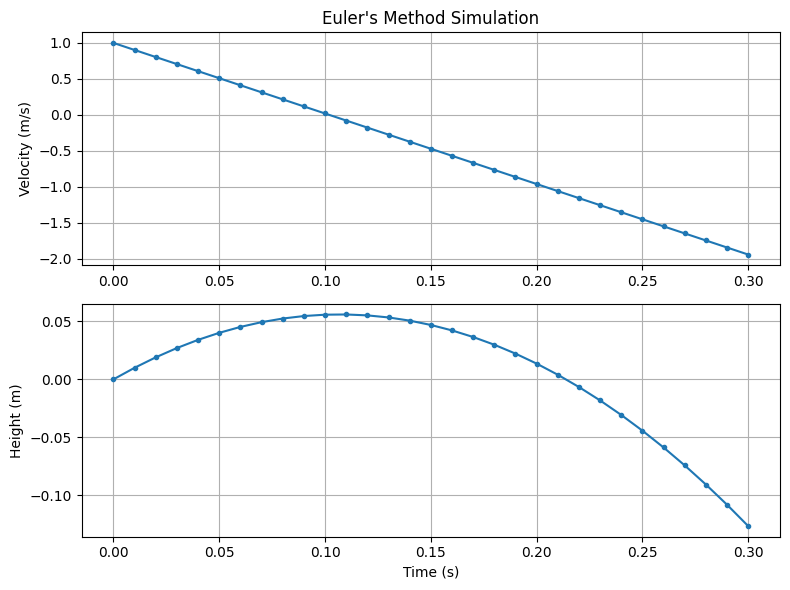

In [1]:
# Your vibe-coded ball-in-flight simulation here:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
g = 9.81
dt = 0.01
t_end = 0.30

# Time array
t = np.arange(0, t_end + dt, dt)

# Initialize arrays
v = np.zeros(len(t))
h = np.zeros(len(t))

# Initial conditions
v[0] = 1.0
h[0] = 0.0

# Euler's method
for i in range(len(t) - 1):
    v[i+1] = v[i] - g * dt
    h[i+1] = h[i] + v[i] * dt

# Plot velocity and height
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(t, v, 'o-', markersize=3)
plt.ylabel("Velocity (m/s)")
plt.title("Euler's Method Simulation")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, h, 'o-', markersize=3)
plt.xlabel("Time (s)")
plt.ylabel("Height (m)")
plt.grid()

plt.tight_layout()
plt.show()

### Step 7 — Interpret
*Your Answer Here — does your simulated peak time match your by-hand answer above? What does the $h(t)$ curve look like once $v$ goes negative — does that match your physical intuition for the ball falling back down?*

Yes it does.

### 📸 Upload Checkpoint 1
On paper, sketch this system fresh — the setup, the state variable, the law, and the equation — without looking back at this notebook. Photograph it and upload below.

**Activity — vibe-code it:** ask an AI assistant to help you write a short Colab cell that lets you upload an image file and display it inline.

In [1]:
# Your image upload + display code here:
from google.colab import files
from IPython.display import display, Image

# Upload an image from your device
uploaded = files.upload("C:\Users\hweit\Downloads\pro-jeUeirCL.jpeg")

# Display the uploaded image inline
for filename in uploaded.keys():
    display(Image(filename=filename))

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (2362629949.py, line 6)

---
## Example 2: Driving a Car
The process is familiar now — this time, you fill in more of it yourself.

### Steps 1-3
**Sketch:** a car accelerating from rest, engine force pushing forward, air resistance/drag pushing back, proportional to velocity ($F_{drag} = -bv$).
**State variable:** velocity $v(t)$.
**Underlying law:** Newton's 2nd law again — but this time there are *two* forces, not one.

### Step 4 — Your Turn
Write the balance equation yourself: $m\dot v = F_{engine} - bv$. Rearrange this into the standard form $\tau \dot v + v = Ku(t)$ from Set 1 — what are $\tau$ and $K$ in terms of $m$, $b$, and $F_{engine}$?

*Your Answer Here:*
Tau = m/b and K= F engine/b

**Activity — vibe-code it:** simulate this system for $m=1000$ kg, $b=50$ N·s/m, $F_{engine}=2000$ N, starting from rest. Plot $v(t)$.

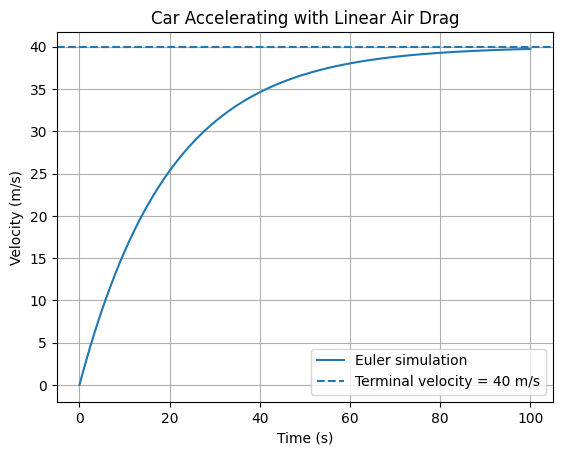

In [2]:
# Your vibe-coded car simulation here:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 1000.0
b = 50.0
F_engine = 2000.0

# Time settings
dt = 0.1
t_end = 100
t = np.arange(0, t_end + dt, dt)

# Initialize velocity
v = np.zeros(len(t))
v[0] = 0.0  # starting from rest

# Euler's method
for i in range(len(t) - 1):
    dvdt = (F_engine - b * v[i]) / m
    v[i+1] = v[i] + dt * dvdt

# Plot
plt.plot(t, v, label="Euler simulation")
plt.axhline(40, linestyle="--",
            label="Terminal velocity = 40 m/s")

plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Car Accelerating with Linear Air Drag")
plt.grid()
plt.legend()
plt.show()

*Your Answer Here — what velocity does the car eventually settle at (steady state)? Does increasing drag $b$ increase or decrease that steady-state speed, and does that match your intuition?*
It steadys at 40 m/s. The drag increases with the more force being applied.

---
## Example 3: A Tank Filling With Outflow
### Steps 1-3
**Sketch:** a tank with a faucet adding fluid at a constant rate, and an outflow drain removing fluid at a rate proportional to the fluid level (more pressure at higher levels pushes more fluid out).
**State variable:** fluid level $h(t)$.
**Underlying law:** conservation of volume — $q_{in} - q_{out} = \text{Area} \times \dot h$.

### Step 4 — Your Turn
With $q_{in}$ constant and $q_{out} = c \cdot h$ (proportional to level), write the balance equation and rearrange it into standard form. What plays the role of $\tau$? Of $K$?

*Your Answer Here:*

tau = A/c and K = qin / c

**Activity — vibe-code it:** simulate this tank for Area$=2$ m², $q_{in}=5$ L/s, $c=1$ (L/s per meter of height), starting empty. Plot $h(t)$.

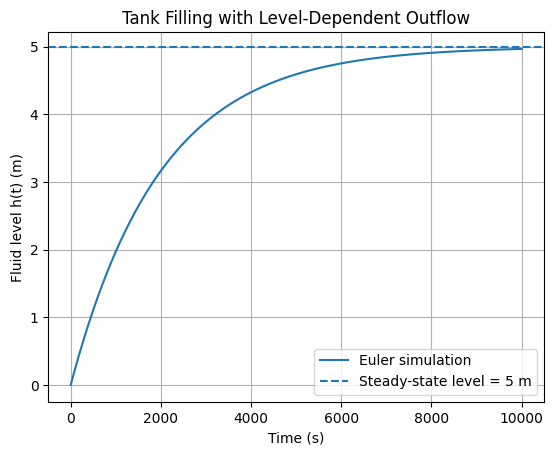

In [3]:
# Your vibe-coded tank simulation here:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
A = 2.0               # m^2
qin = 5.0 / 1000      # m^3/s
c = 1.0 / 1000        # m^2/s

# Time settings
dt = 10.0
t_end = 10000
t = np.arange(0, t_end + dt, dt)

# Initialize height (tank starts empty)
h = np.zeros(len(t))

# Euler's method
for i in range(len(t) - 1):
    dhdt = (qin - c * h[i]) / A
    h[i+1] = h[i] + dt * dhdt

# Plot
plt.plot(t, h, label="Euler simulation")
plt.axhline(5, linestyle="--",
            label="Steady-state level = 5 m")

plt.xlabel("Time (s)")
plt.ylabel("Fluid level h(t) (m)")
plt.title("Tank Filling with Level-Dependent Outflow")
plt.grid()
plt.legend()
plt.show()

*Your Answer Here — what steady-state level does the tank reach? At steady state, what must be true about $q_{in}$ and $q_{out}$?*
5m, and the flows have to be equivelant.

---
## Example 4: How Does a Neuron Charge?
This is where it all connects back. Recall Set 3, Module B — you already built this exact model once.

### Steps 1-3
**Sketch:** a neuron's membrane, current being injected, some current charging the membrane capacitance, some current leaking out through leak channels.
**State variable:** membrane voltage $V_m(t)$.
**Underlying laws:** conservation of charge (injected current splits between charging the capacitor and flowing through the leak resistance) — **and** Ohm's law, to describe the leak current itself. Two laws working together, exactly like the board's fourth entry.

### Step 4 — Recall, Don't Re-derive
You already derived this by hand in Set 3:
$$C\frac{dV_m}{dt} = -\frac{1}{R}(V_m - E_{leak}) + I_{inject}$$

**Activity — Ask AI:** *"Given everything covered in this notebook about first-order systems, explain why the neuron membrane equation and the tank-filling equation have the exact same mathematical structure, even though one involves electrical charge and the other involves fluid volume."* Paste the response.

The neuron membrane equation and the tank-filling equation have the same mathematical structure because both are first-order systems that describe how a quantity changes over time based on an input and a resistance-like effect that opposes the change.

For the tank, the fluid level changes according to the difference between the constant inflow and the outflow, which is proportional to the fluid level. For the neuron, the membrane voltage changes based on the injected current and the leak current, which depends on the difference between the membrane voltage and the leak potential.

Both equations can be rearranged into the standard first-order form:

τ
dt
dx
	​

+x=Ku(t)+constant

In both systems, the time constant determines how quickly the system responds, while the steady-state value is determined by the input and system parameters. The key idea is that different physical systems can have identical mathematical dynamics, allowing engineers to use the same tools—such as Euler's method, time-constant analysis, and steady-state analysis—to understand both fluid systems and electrical systems

*Your Answer Here — in your own words, what does capacitance $C$ correspond to in the tank example? What does leak conductance $1/R$ correspond to?*

C is a component of the time constant and 1/R is the Kvalue.

---
## Pause and Reflect: The Pattern
Four systems, two families of laws, one mathematical structure. Before moving on, fill in the blanks yourself:

*Your Answer Here — for each of the four examples above, what plays the role of $\tau$ (how fast the system responds) and $K$ (where it eventually settles)?*

---
## Design Challenges: New Systems, Same Process
Three new scenarios — none of them on the board, none of them worked out for you. Run the full 7-step process on each, on your own.

### Challenge 1 — A Draining Bathtub
A bathtub full of water has its drain opened, with no faucet running. The outflow rate is proportional to the water level.

Run the process yourself: sketch, state variable, law, balance equation, standard form, then vibe-code a simulation.

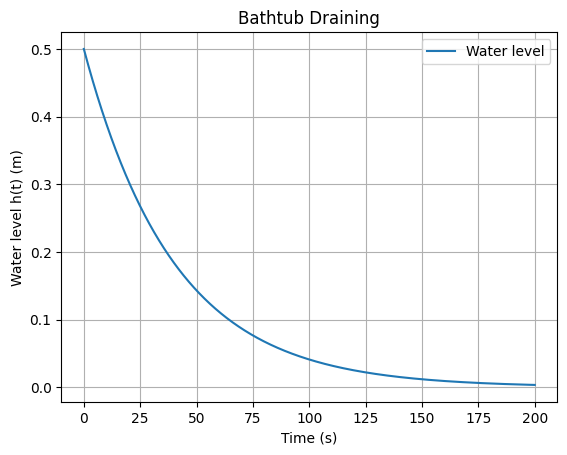

In [4]:
# Your bathtub-draining code here:
import numpy as np
import matplotlib.pyplot as plt

# Bathtub parameters
A = 0.8       # Area (m^2)
c = 0.02      # Drain coefficient (m^2/s)
h0 = 0.50     # Initial water level (m)

# Time settings
dt = 0.1
t_end = 200
t = np.arange(0, t_end + dt, dt)

# Initialize water level
h = np.zeros(len(t))
h[0] = h0

# Euler's method
for i in range(len(t) - 1):
    dhdt = -(c / A) * h[i]
    h[i+1] = h[i] + dt * dhdt

# Plot water level
plt.plot(t, h, label="Water level")
plt.xlabel("Time (s)")
plt.ylabel("Water level h(t) (m)")
plt.title("Bathtub Draining")
plt.grid()
plt.legend()
plt.show()

*Your Answer Here — how is this related to Example 3? What's different about the steady-state behavior?*

It uses the same physical laws of flow rate, but this time without a second constant input value.

### Challenge 2 — Coffee Cooling
A hot cup of coffee cools toward room temperature. Newton's Law of Cooling states the rate of heat loss is proportional to the difference between the coffee's temperature and the room's temperature.

Run the process yourself.

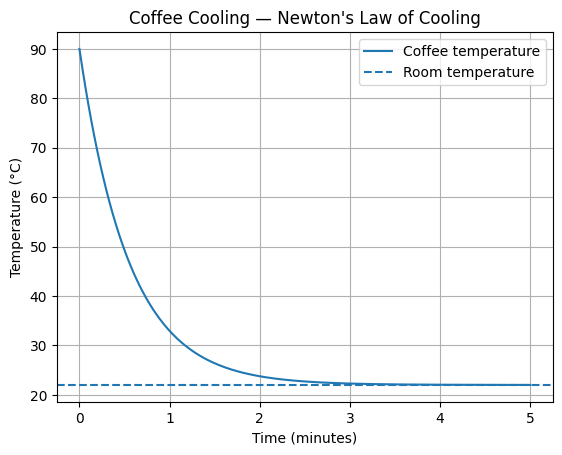

In [5]:
# Your coffee-cooling code here:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T_room = 22.0   # Room temperature (°C)
T0 = 90.0       # Initial coffee temperature (°C)
k = 0.03        # Cooling constant (1/s)

# Time settings
dt = 1.0
t_end = 300
t = np.arange(0, t_end + dt, dt)

# Initialize temperature
T = np.zeros(len(t))
T[0] = T0

# Euler's method
for i in range(len(t) - 1):
    dTdt = -k * (T[i] - T_room)
    T[i+1] = T[i] + dt * dTdt

# Plot temperature
plt.plot(t / 60, T, label="Coffee temperature")
plt.axhline(T_room, linestyle="--",
            label="Room temperature")

plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.title("Coffee Cooling — Newton's Law of Cooling")
plt.grid()
plt.legend()
plt.show()

*Your Answer Here — which of the four blackboard examples does this most resemble mathematically, even though it's a completely different physical phenomenon?* It mirrors the discharge of a neuron most similarly.

### Challenge 3 — Drug Concentration Decay
After a single dose, a drug's concentration in the bloodstream decreases at a rate proportional to how much is currently present (the body metabolizes it at a rate proportional to concentration).

Run the process yourself.

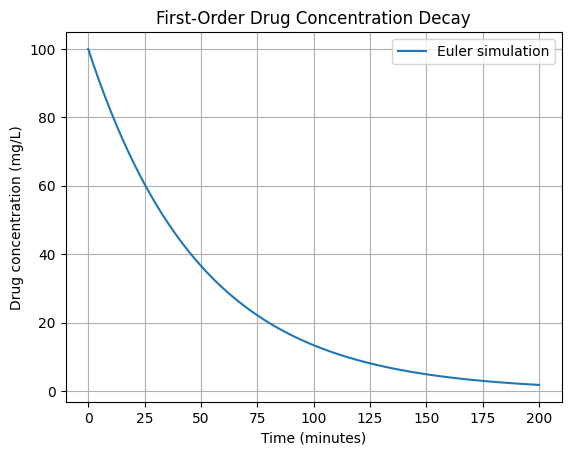

In [6]:
# Your drug-decay code here:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
C0 = 100.0       # Initial concentration (mg/L)
k = 0.02         # Elimination rate constant (1/min)

# Time settings
dt = 0.5
t_end = 200
t = np.arange(0, t_end + dt, dt)

# Initialize concentration
C = np.zeros(len(t))
C[0] = C0

# Euler's method
for i in range(len(t) - 1):
    dCdt = -k * C[i]
    C[i+1] = C[i] + dt * dCdt

# Plot
plt.plot(t, C, label="Euler simulation")
plt.xlabel("Time (minutes)")
plt.ylabel("Drug concentration (mg/L)")
plt.title("First-Order Drug Concentration Decay")
plt.grid()
plt.legend()
plt.show()

*Your Answer Here — is there a $K$ (nonzero steady state) in this system, or does it decay to zero? What does that tell you about the difference between this system and Example 3?*

There is a K value, and it means that it steadies out at a linear rate of decay instead of a net equilibrium.

---
## Capstone: Predator and Prey — A Coupled System
Every example so far has had **one** state variable. Real systems often have several, influencing each other. Predator-prey population dynamics — a classic biological modeling problem — is a natural next step: still first-order (only first derivatives appear), but now **two** equations, **coupled** together, and genuinely **nonlinear**.

### Steps 1-3
**Sketch:** a population of prey (e.g., rabbits) and a population of predators (e.g., foxes) sharing an ecosystem.
**State variables:** prey population $R(t)$, predator population $F(t)$ — *two* state variables tracked simultaneously.
**Underlying law:** conservation of population, applied separately to each species, with a coupling term for predator-prey encounters.

### Step 4 — The Balance Equations
$$\dot R = aR - bRF$$
$$\dot F = -cF + dRF$$

**Activity — Ask AI:** *"In the Lotka-Volterra predator-prey equations, explain what each of the four terms (aR, bRF, cF, dRF) physically represents, and why the interaction terms bRF and dRF have opposite signs in the two equations."* Paste the response.

In the Lotka-Volterra predator-prey equations, each term represents a biological process that affects the prey or predator population over time.

The equations are:

R
˙
=aR−bRF
F
˙
=−cF+dRF
What each term represents

- aR — Prey growth: The prey population (rabbits) grows naturally through reproduction when predators are absent. The parameter a is the prey's growth rate.

- bRF — Prey loss from predation: When predators (foxes) encounter prey, they consume them, reducing the prey population. This term depends on both populations because more rabbits and foxes lead to more encounters. The parameter b represents the predation rate.

- cF — Predator decline: In the absence of prey, the predator population decreases because of factors such as starvation and natural mortality. The parameter c is the predator's death rate.

- dRF — Predator growth from feeding: When predators consume prey, they gain energy that supports survival and reproduction, increasing the predator population. This term depends on encounters between rabbits and foxes. The parameter d represents how effectively those encounters contribute to predator growth.

Why do the interaction terms have opposite signs?

The terms bRF and dRF describe the same predator-prey interaction, but its effects on the two populations are different:

In the prey equation, −bRF is negative because predation removes rabbits from the population.

In the predator equation, +dRF is positive because consuming rabbits provides energy that supports fox survival and reproduction.

Key takeaway: The interaction terms couple the two differential equations. The prey population affects predator growth, while the predator population affects prey decline. This coupling can produce oscillations in both populations over time, as changes in one population influence the other.

*Your Answer Here — in your own words, why does $R$ grow exponentially ($aR$) when no predators are present?*
It grows exponentially because it is above replacement level, so the added population starts adding more in addition to the previous population. This causes exponential growth.

### Steps 5-7 — Parameters, Simulation, Interpretation
**Activity — vibe-code it:** ask an AI assistant to help you build a coupled Euler's-method simulation of both equations together (both $R$ and $F$ must be updated using values from the *same* previous time step — a genuinely new wrinkle compared to every single-variable example above). Try $a=1.0$, $b=0.1$, $c=1.5$, $d=0.075$, starting from $R(0)=10$, $F(0)=5$. Plot both populations over time, **and** a phase-plane plot ($F$ vs. $R$, not vs. time — recall this style of plot from Set 5's D11).

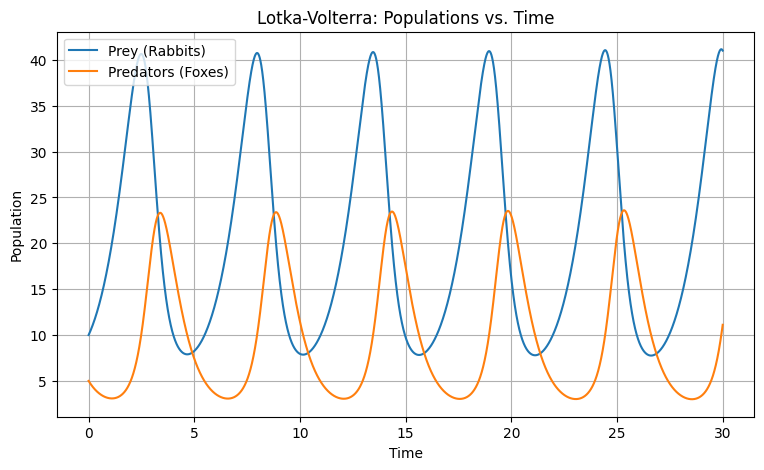

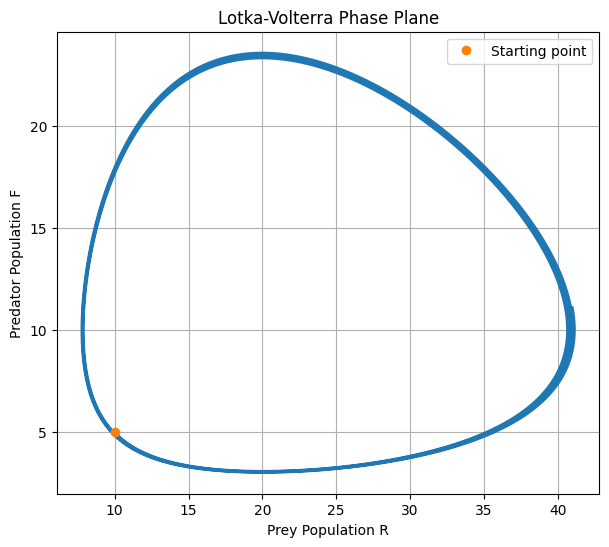

In [7]:
# Your vibe-coded coupled predator-prey simulation here:

import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 1.0
b = 0.1
c = 1.5
d = 0.075

# Initial populations
R0 = 10.0
F0 = 5.0

# Time settings
dt = 0.001
t_end = 30.0
t = np.arange(0, t_end + dt, dt)

# Initialize population arrays
R = np.zeros(len(t))
F = np.zeros(len(t))

R[0] = R0
F[0] = F0

# Coupled Euler's method
for n in range(len(t) - 1):

    # Calculate BOTH derivatives using old values
    dRdt = a * R[n] - b * R[n] * F[n]
    dFdt = -c * F[n] + d * R[n] * F[n]

    # Update both populations
    R[n+1] = R[n] + dt * dRdt
    F[n+1] = F[n] + dt * dFdt

# Plot populations vs. time
plt.figure(figsize=(9, 5))
plt.plot(t, R, label="Prey (Rabbits)")
plt.plot(t, F, label="Predators (Foxes)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Lotka-Volterra: Populations vs. Time")
plt.legend()
plt.grid()
plt.show()

# Phase-plane plot: F vs R
plt.figure(figsize=(7, 6))
plt.plot(R, F)
plt.plot(R[0], F[0], "o", label="Starting point")
plt.xlabel("Prey Population R")
plt.ylabel("Predator Population F")
plt.title("Lotka-Volterra Phase Plane")
plt.legend()
plt.grid()
plt.show()

*Your Answer Here — describe the pattern in your time-series plot. Does either population settle to a steady value, the way every earlier example did? What does the phase-plane plot look like, and what does that shape tell you about the long-term behavior?*

It did not settle, and the phase plane plot looked circular. This tells me that the long term behavior is cyclic.

### 📸 Upload Checkpoint 2
On paper, sketch this coupled system fresh — both populations, the interaction between them, and both balance equations — without looking back. This is harder than Checkpoint 1: you're now sketching *two* interacting state variables, not one. Photograph and upload.

In [8]:
# Your image upload + display code here:
# Your image upload + display code here:
from google.colab import files
from IPython.display import display, Image

# Upload an image from your device
uploaded = files.upload("C:\Users\hweit\Downloads\pro-3fu6RTH9.jpeg")

# Display the uploaded image inline
for filename in uploaded.keys():
    display(Image(filename=filename))

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2642490597.py, line 7)

---
## Find Your Own First-Order System
This is the real test of transfer. Pick a system from *any* field — your own major, a hobby, something you're just curious about — that you believe has first-order (or coupled first-order) dynamics. It does not have to be biological or physical in the traditional sense; economics, social dynamics, and epidemiology all have genuine first-order examples too.

Run the full 7-step process on it yourself: sketch, state variable(s), underlying law(s), balance equation, parameters, a vibe-coded simulation, and your own interpretation of the result.

There's no template for this one — that's the point.

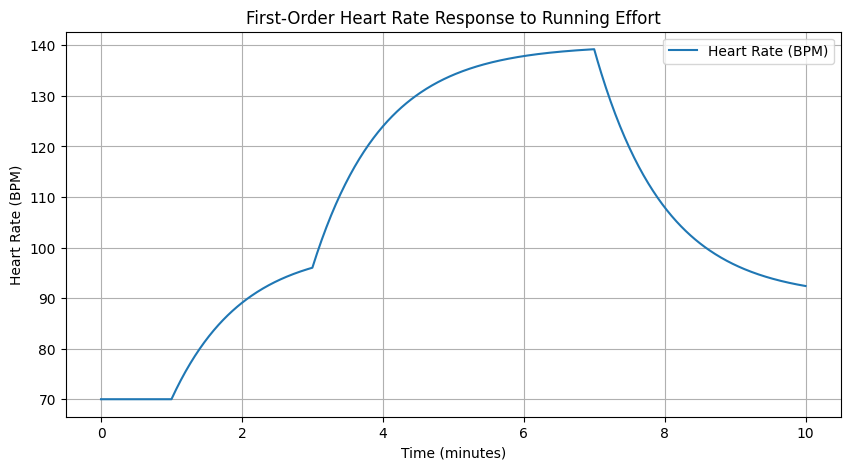

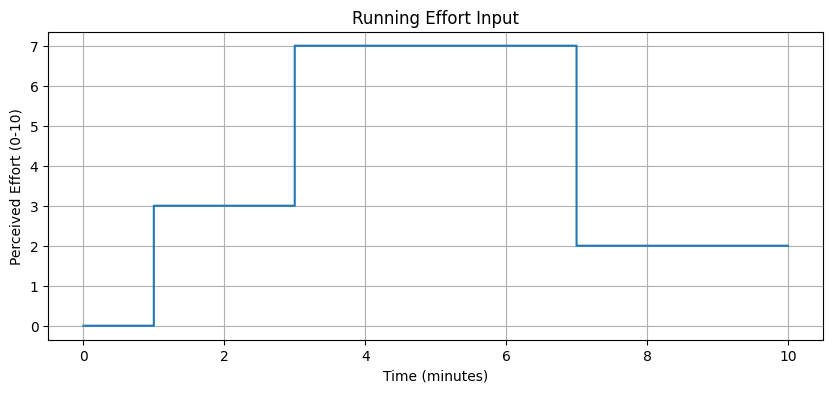

In [9]:
# Your vibe-coded simulation of your own chosen system here:

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# Parameters (illustrative only)
# --------------------------------
HR_rest = 70       # Resting heart rate (BPM)
K = 10             # BPM increase per effort unit
tau = 60           # Heart rate response time constant (seconds)

# Time settings
dt = 1.0
t_end = 600        # 10 minutes
t = np.arange(0, t_end + dt, dt)

# --------------------------------
# Perceived effort input (0-10)
# --------------------------------
E = np.zeros(len(t))

# 0-1 min: easy effort (3/10)
E[(t >= 60) & (t < 180)] = 3

# 3-7 min: harder effort (7/10)
E[(t >= 180) & (t < 420)] = 7

# 7-10 min: recovery jog (2/10)
E[t >= 420] = 2

# --------------------------------
# Initialize heart rate
# --------------------------------
HR = np.zeros(len(t))
HR[0] = HR_rest

# --------------------------------
# Euler's method
# --------------------------------
for i in range(len(t) - 1):

    # Target HR based on current effort
    HR_target = HR_rest + K * E[i]

    # First-order differential equation
    dHRdt = (HR_target - HR[i]) / tau

    # Euler update
    HR[i+1] = HR[i] + dt * dHRdt

# --------------------------------
# Plot results
# --------------------------------
plt.figure(figsize=(10, 5))

plt.plot(t / 60, HR, label="Heart Rate (BPM)")
plt.xlabel("Time (minutes)")
plt.ylabel("Heart Rate (BPM)")
plt.title("First-Order Heart Rate Response to Running Effort")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------
# Plot perceived effort
# --------------------------------
plt.figure(figsize=(10, 4))

plt.step(t / 60, E, where="post")
plt.xlabel("Time (minutes)")
plt.ylabel("Perceived Effort (0-10)")
plt.title("Running Effort Input")
plt.grid(True)
plt.show()

*Your Answer Here — describe your system, your reasoning, and what you learned from simulating it:*

### 📸 Upload Checkpoint 3
Photograph your hand-sketch of this system — the setup, the state variable(s), the law(s), and the equation(s) — and upload it below.

In [ ]:
# Your image upload + display code here:


---
## The Big Picture: One Table, Every System
You've now modeled seven systems (four worked examples, three design challenges) plus a coupled two-variable system, plus one of your own. Time to see them all at once.

**On paper, from memory — do not scroll back through this notebook to copy answers** — recreate a table with these columns: **System | Independent Variable | Dependent Variable | Underlying Law(s)**. Include every system from this notebook: the ball, the car, the tank, the neuron, the bathtub, the coffee, the drug decay, both predator-prey populations, and your own found system.

This is deliberately hard to do perfectly from memory — that's exactly what makes it a genuine test of whether the *pattern* consolidated, not just whether each individual example made sense at the time you worked through it.

### 📸 Upload Checkpoint 4 — The Summary Table
Photograph your completed table and upload it below. This is the closing checkpoint of the entire notebook.

In [ ]:
# Your image upload + display code here:


---
## Homework: This Is What Quizzes and Exams Will Look Like
- **By hand, no AI:** the ball-in-flight velocity/peak-time drill
- **Design deliverables:** the bathtub, coffee-cooling, and drug-decay simulations, plus your own found system
- **The coupled predator-prey simulation**, including both time-series and phase-plane plots
- **Four upload checkpoints:** the ball sketch, the predator-prey sketch, your own system's sketch, and the final summary table

*(Exact grading weight for this notebook depends on where it's placed in the course sequence — to be determined by the instructor.)*

---
## Knowledge Bank — First-Order Systems: A Modeling Process

**This is the outcome of this module.** For anything you're unsure about, use an AI assistant to research it, and add what you find as your own notes right in this notebook.

### A. The General Process
1. List all seven steps of the modeling process used throughout this notebook, in order.
2. What does it mean for two systems from different fields to "have the same mathematical structure"?
3. Why is identifying the state variable (Step 2) necessary before you can write a balance equation?

### B. The Four Core Examples
4. For the ball-in-flight example, what physical law produces $\ddot h = -g$?
5. Explain the trick of letting $v=\dot h$ to turn a second-order equation into a first-order one. Does this trick require the original equation to be linear?
6. For the car example, what role does the drag term $-bv$ play in the equation's standard form ($\tau\dot v + v = Ku$)?
7. For the tank example, state the conservation law in words, then in symbols.
8. Explain why the neuron charging example needs *two* laws (conservation of charge and Ohm's law) while the ball example needs only one.

### C. Transfer to New Systems
9. For the draining-bathtub challenge, does the system have a nonzero steady state? Why or why not, physically?
10. State Newton's Law of Cooling in your own words, and identify which earlier example it most closely resembles mathematically.
11. For the drug-decay challenge, why does this system decay to zero rather than settling at some nonzero steady value, unlike the tank example?

### D. Predator-Prey and Coupled Systems
12. Write both Lotka-Volterra equations from memory, and explain what each term represents.
13. Why are the interaction terms $bRF$ and $dRF$ given opposite signs in the two equations?
14. What does a closed loop in a predator-prey phase-plane plot indicate about the long-term behavior of both populations?
15. Is the predator-prey system linear or nonlinear? What specifically makes it nonlinear?
16. Why can't the coupled predator-prey system generally be solved with a simple closed-form formula the way the single-variable examples could?

### E. Synthesis
17. Name two systems from this notebook that share the same underlying law but come from completely different fields.
18. If you were shown a brand-new dynamic system tomorrow, in a field not covered in this notebook, what is the first step you'd take to start modeling it?
19. What is the difference between a system having first-order dynamics and a system being linear? (Hint: think about predator-prey.)

---
### 🎯 Your Turn — Design Two Questions, Not Just Answer Them
Pick any concept from this notebook. Create **two** short questions of your own — one of each type:

**1. An Analysis-type question:** present a scenario, plot, or result, and ask the reader to interpret *why* something happened or what it implies.

**2. A Design-type question:** ask the reader *how* to achieve a specific target outcome, or what change would produce a given effect.

For each: include a brief setup, 2–4 possible answers, the correct answer, and a short explanation of why. No required format or topic beyond that — design both however makes sense to you.

*Your Analysis-type question, answers, and explanation here:*

*Your Design-type question, answers, and explanation here:*

---
## References
* Modeling process and worked examples adapted from course blackboard materials: *The World of First-Order Systems*, Nair SS, et al., Electrical Engineering and Computer Science, University of Missouri-Columbia, Columbia, MO, USA.
* Lotka, A. J. (1925). *Elements of Physical Biology*. Williams & Wilkins.
* Volterra, V. (1926). Variazioni e fluttuazioni del numero d'individui in specie animali conviventi. *Mem. Acad. Lincei Roma*, 2, 31-113.